# Inference Pipeline

This notebook demonstrates how the trained Convolutional Neural Network (CNN) model is used to classify new urban noise recordings.

The inference pipeline performs the following steps:

1. Load the trained CNN model
2. Load the label encoder
3. Load an audio file
4. Generate a Mel Spectrogram
5. Prepare the spectrogram for prediction
6. Predict the noise category
7. Display confidence scores

This notebook serves as a prototype for the future API deployment.

In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

from tensorflow.keras.models import load_model

## Load Trained Model and Label Encoder

The CNN model and label encoder generated during training are loaded from Google Drive.

In [3]:
MODEL_PATH = "/content/drive/MyDrive/UrbanNoiseProject/models/urban_noise_cnn.keras"

ENCODER_PATH = "/content/drive/MyDrive/UrbanNoiseProject/models/label_encoder.pkl"

cnn_model = load_model(MODEL_PATH)

label_encoder = joblib.load(ENCODER_PATH)

print("Model loaded successfully.")
print("Classes:")
print(label_encoder.classes_)

Model loaded successfully.
Classes:
['Ambience' 'Construction' 'Entertainment' 'Traffic']


## Select Test Audio File

A sample audio recording is loaded from the UrbanSound8K dataset.

In [4]:
AUDIO_PATH = "/content/drive/MyDrive/UrbanNoiseProject/datasets/UrbanSound8K/fold1/101415-3-0-2.wav"

audio, sr = librosa.load(
    AUDIO_PATH,
    sr=22050
)

print("Sample Rate:", sr)
print("Audio Length:", len(audio))

Sample Rate: 22050
Audio Length: 88200


## Visualize Audio Waveform

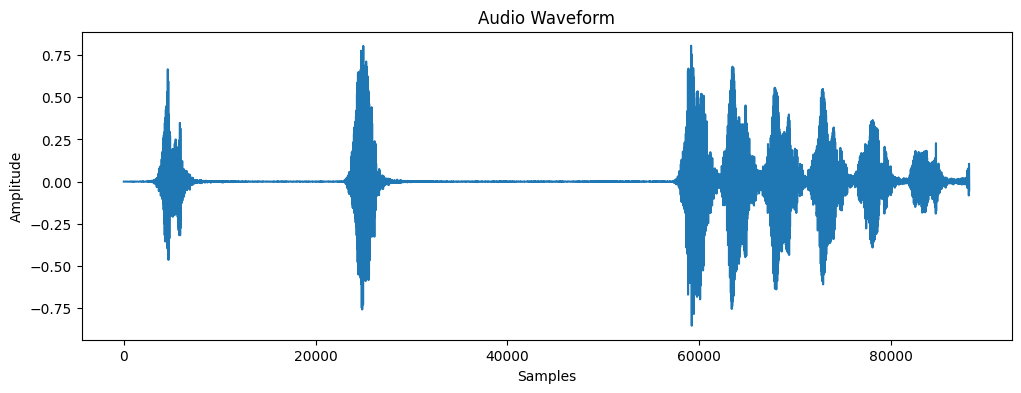

In [5]:
plt.figure(figsize=(12,4))

plt.plot(audio)

plt.title("Audio Waveform")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.show()

## Generate Mel Spectrogram

The audio signal is transformed into a Mel Spectrogram, which is the same representation used during CNN training.

In [6]:
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print(mel_spec_db.shape)

(128, 173)


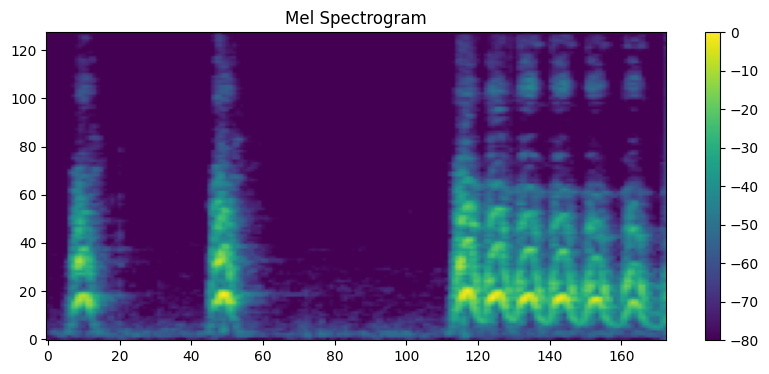

In [7]:
plt.figure(figsize=(10,4))

plt.imshow(
    mel_spec_db,
    aspect="auto",
    origin="lower"
)

plt.title("Mel Spectrogram")
plt.colorbar()

plt.show()

## Resize Spectrogram

The CNN expects input dimensions of 128 × 128.

In [8]:
mel_spec_db = mel_spec_db[:, :128]

if mel_spec_db.shape[1] < 128:
    padding = 128 - mel_spec_db.shape[1]

    mel_spec_db = np.pad(
        mel_spec_db,
        ((0,0),(0,padding)),
        mode="constant"
    )

print(mel_spec_db.shape)

(128, 128)


## Prepare Input Tensor

The spectrogram is reshaped into the format required by the CNN.

In [9]:
X_input = mel_spec_db.reshape(
    1,
    128,
    128,
    1
)

print(X_input.shape)

(1, 128, 128, 1)


## Generate Prediction

In [10]:
prediction = cnn_model.predict(X_input)

prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[9.997354e-01, 7.128930e-08, 2.516241e-04, 1.294612e-05]],
      dtype=float32)

In [11]:
predicted_index = np.argmax(prediction)

predicted_class = label_encoder.inverse_transform(
    [predicted_index]
)[0]

confidence = np.max(prediction)

print("Predicted Category:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")

Predicted Category: Ambience
Confidence: 99.97 %


## Display Confidence Scores for All Classes

In [12]:
class_names = label_encoder.classes_

scores = prediction[0]

for name, score in zip(class_names, scores):
    print(
        f"{name}: {score*100:.2f}%"
    )

Ambience: 99.97%
Construction: 0.00%
Entertainment: 0.03%
Traffic: 0.00%


## Conclusion

The inference pipeline successfully processes a new audio recording and predicts its urban noise category.

This workflow will be reused in the deployment phase through a FastAPI service and Swagger UI interface.